<h1>Contenido<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#ESTADÍSTICA-II-PARA-DATA-SCIENCE:-INFERENCIAL" data-toc-modified-id="ESTADÍSTICA-II-PARA-DATA-SCIENCE:-INFERENCIAL-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>ESTADÍSTICA II PARA DATA SCIENCE: INFERENCIAL</a></span><ul class="toc-item"><li><span><a href="#PREPARACION" data-toc-modified-id="PREPARACION-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>PREPARACION</a></span></li><li><span><a href="#ESTADÍSTICA-INFERENCIAL" data-toc-modified-id="ESTADÍSTICA-INFERENCIAL-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>ESTADÍSTICA INFERENCIAL</a></span><ul class="toc-item"><li><span><a href="#Distribuciones" data-toc-modified-id="Distribuciones-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Distribuciones</a></span><ul class="toc-item"><li><span><a href="#Distribuciones-discretas" data-toc-modified-id="Distribuciones-discretas-1.2.1.1"><span class="toc-item-num">1.2.1.1&nbsp;&nbsp;</span>Distribuciones discretas</a></span></li><li><span><a href="#Distribuciones-continuas" data-toc-modified-id="Distribuciones-continuas-1.2.1.2"><span class="toc-item-num">1.2.1.2&nbsp;&nbsp;</span>Distribuciones continuas</a></span></li></ul></li><li><span><a href="#Teorema-del-Límite-Central" data-toc-modified-id="Teorema-del-Límite-Central-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Teorema del Límite Central</a></span></li><li><span><a href="#Cálculo-de-intervalos-de-confianza" data-toc-modified-id="Cálculo-de-intervalos-de-confianza-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Cálculo de intervalos de confianza</a></span></li><li><span><a href="#Muestreo" data-toc-modified-id="Muestreo-1.2.4"><span class="toc-item-num">1.2.4&nbsp;&nbsp;</span>Muestreo</a></span></li><li><span><a href="#Alpha-y-pvalor" data-toc-modified-id="Alpha-y-pvalor-1.2.5"><span class="toc-item-num">1.2.5&nbsp;&nbsp;</span>Alpha y pvalor</a></span></li><li><span><a href="#Contraste-de-hipótesis" data-toc-modified-id="Contraste-de-hipótesis-1.2.6"><span class="toc-item-num">1.2.6&nbsp;&nbsp;</span>Contraste de hipótesis</a></span></li></ul></li></ul></li></ul></div>

# ESTADÍSTICA II PARA DATA SCIENCE: INFERENCIAL


#### Nota Codex

Este cuaderno es una copia enriquecida del material oficial. Conserva el contenido de inferencia estadística y añade precisiones sobre interpretación, condiciones de uso y conceptos que suelen faltar al empezar.


## PREPARACION

In [68]:
#Carga de paquetes y datos
import pandas as pd
import numpy as np
import statistics
import scipy as sp
import seaborn as sns
import random
import math
from statsmodels.stats.proportion import proportions_ztest

df = sns.load_dataset('tips')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [70]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## ESTADÍSTICA INFERENCIAL

La estadística inferencial nos da herramientas para poder estimar **cómo de robustos y representativos del dato "real" en la población son las conclusiones que estamos obteniendo mediante nuestros análisis en la muestra**.

Ya sabemos que la población es el total de elementos sobre el cual estamos intentando obtener conclusiones. Y en la mayoría de los casos será un ideal ya que operativamente no podremos nunca acceder a él.

Por ejemplo si queremos estudiar los hábitos de compra de los españoles nunca podremos hacer una encuesta ni recopilar datos de TODOS los españoles.

O si estamos analizando los clientes de una empresa realmente nunca podremos analizar el total de clientes potenciales a los que esa empresa podría algún día llegar a tener como clientes.

Por ello en la práctica se entiende que siempre estaremos trabajando con una muestra de esa población.

(Tener en cuenta las notas que comentamos al inicio de este módulo sobre el grado en el que podemos considerar como realmente aleatoria una muestra que tenemos en un contexto empresarial)

Sobre esa muestra haremos nuestros análisis y obtendremos unas conclusiones, pero no sabemos hasta qué punto esas conclusiones o datos se acercan al dato "real" que obtendríamos si pudiéramos analizar toda la población.

En la práctica usaremos la **estadística inferencial** sobre todo para:

* Validar que el dato que hemos obtenido en la muestra es, bajo unas condiciones probabilísticas, un dato correcto, robusto y extrapolable
* Conocer los límites o intervalos superior e inferiores al dato que podríamos considerar válidos
* Aceptar o rechazar ciertas conclusiones (hipótesis) que queramos poner a prueba

En términos técnicos los puntos anteriores se cubren mediante lo que se llama:

1. Estimación de intervalos de confianza
2. Contraste de hipótesis

Además por el camino aprenderemos sobre distribuciones de probabilidad, y cómo hacer muestras (algo que aún en tiempos de Big Data sigue siendo de mucha utilidad).


### Distribuciones


#### Nota Codex - Para qué sirven las distribuciones

Una distribución no es solo un dibujo: es un modelo de incertidumbre. Nos permite responder preguntas del tipo: qué valores son esperables, qué valores son raros y qué probabilidad tiene un evento.


Una distribución es una función que muestra los **posibles valores de una variable y como de frecuente o probable es que ocurra cada uno**.

Es un concepto clave para todo lo que vamos ver después, especialmente la distribución que se llama normal o curva de Gauss.

La gran clave conceptual de la utilidad de las distribuciones es que pueden ser definidas por unos parámetros, y por tanto conocidas en todo su recorrido.

Por tanto, si cuando estamos analizando un evento, descubrimos que ese evento parece seguir una distribución conocida, es como tener un mapa, o como conocer las preguntas del examen.

Ya que podremos utilizar ese conocimiento de la distribución para hacer predicciones o contrastar hipótesis.

Por ejemplo se ha visto que lo que se llama "teoría de colas", como el número de llamadas que entran por unidad de tiempo en un call center, suele seguir la distribución de Poisson. Así que si queremos dimensionar adecuadamente un call center podemos usar esta distribución para predecir probabilísticamente el número de llamadas que entrarán y dimensionar en consecuencia.

Podemos hacer una gran clasificación de las distribuciones entre:

* Distribuciones de variables discretas: Bernouilli, Binomial, Poisson
* Distribuciones de variables continuas: Normal, T de Student, distribución F

Las discretas las vamos a repasar brevemente y poner ejemplos gráficos para que te suenen. Y en las contínuas realmente nos vamos a centrar en la distribución Normal que es la más imporante para todo lo que vamos a ver después.

#### Distribuciones discretas


#### Nota Codex - Para qué sirven las distribuciones

Una distribución no es solo un dibujo: es un modelo de incertidumbre. Nos permite responder preguntas del tipo: qué valores son esperables, qué valores son raros y qué probabilidad tiene un evento.


**Bernouilli**

Sigue esta distribución todo experimento aleatorio en que solo pueden ocurrir dos sucesos que además son mutuamente excluyentes.

El ejemplo más clásico es tirar una moneda.

Los eventos no tienen por que ser 50%-50% pueden tener diferentes probabilidades siempre que sumen 100%.

In [71]:
#Ejemplo de una moneda trucada para que el 70% de las veces salga cara
from scipy.stats import bernoulli
moneda = bernoulli.rvs(size=100,p=0.7)
moneda

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

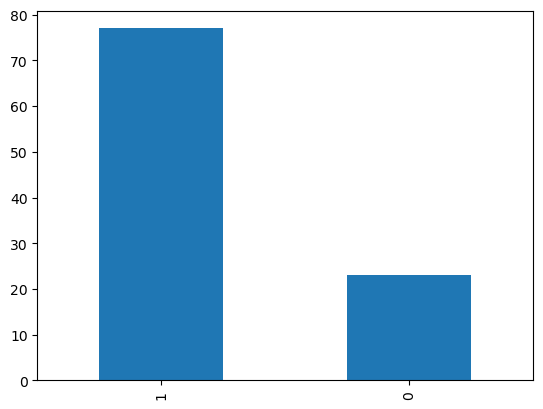

In [72]:
pd.Series(moneda).value_counts().plot(kind = 'bar');

Aunque es una distribución muy simple es el concepto base sobre el que se van a construir modelos como la regresión logística o en general cualquier clasficador binario.

**Binomial**

Sigue esta distribución la suma de los "éxitos" (los unos) que se obtienen en n repeticiones de un experimento de Bernouilli donde la probabilidad (p) de unos se mantiene constante.

Por ejemplo si tiro una moneda (no sesgada) 10 veces, y repito ese experimento 100 veces, ¿en cuantos de esos experimentos obtendré 0 caras, 1 cara, 2 caras, etc.

A medida que n aumenta, y siempre que p no tome valores muy extremos la binomial tiende hacia la normal. Así que en la práctica podremos usar la normal como un proxy en muchas ocasiones.

In [73]:
from scipy.stats import binom
monedas = binom.rvs(n=10,p=0.5,size=100)
monedas

array([5, 7, 4, 5, 4, 3, 4, 5, 6, 7, 6, 4, 7, 2, 7, 7, 3, 5, 3, 6, 7, 5,
       6, 4, 5, 4, 7, 6, 3, 8, 2, 8, 4, 3, 6, 6, 4, 7, 6, 6, 5, 5, 3, 4,
       7, 5, 6, 6, 7, 1, 4, 7, 7, 5, 5, 6, 4, 7, 4, 5, 7, 4, 6, 5, 4, 6,
       5, 6, 7, 7, 7, 3, 2, 3, 4, 6, 5, 4, 5, 2, 5, 5, 6, 6, 5, 3, 4, 4,
       6, 7, 7, 2, 4, 4, 3, 7, 6, 2, 6, 3])

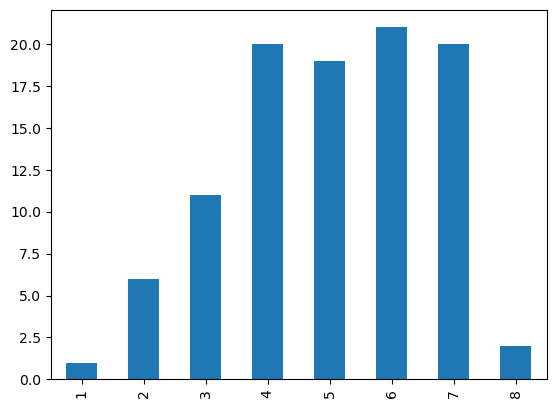

In [74]:
pd.Series(monedas).value_counts().sort_index().plot(kind = 'bar');

A nivel práctico muchas veces es útil calcular la distribución acumulada (Cumulative Distribution Function o cdf).

Por ejemplo si queremos responder a ¿cuántas compras tendremos cada día por cada 1000 visitas si tenemos un 3% de conversión?

Entonces usaríamos el muestreo de valores aleatorios (Random Variates Sampling) o rvs.

El size en este caso es el número de días que simulamos.

In [75]:
binom.rvs(n=1000, p=0.03, size=5)

array([44, 27, 21, 27, 35])

Pero si queremos responder a preguntas como ¿cual es la probabilidad de que en un día tengamos 20 o menos ventas?

Entonces usaríamos la acumulada cdf.

In [76]:
binom.cdf(23, n=1000, p=0.03) # p=0.03 => 3% de probabilidad de éxito, n=1000 => 1000 ensayos, 23 => número de éxitos

np.float64(0.11103505640682616)

Sería bastante raro, solo hay una probabilidad del 3,3% de que pase eso.

**Poisson**

Trata de predecir el número de veces que un evento ocurrirá en un intervalo de tiempo.

Por ejemplo lo que decíamos de teoría de colas en un call center. O el número de pacientes de urgencias que llegarán cada hora.

El parámetro que la define es Lambda: la media del número de eventos por intervalo de tiempo.

Conforme Lambda se aleja de valores muy bajos esta distribución tiende hacia la normal.

También es especialmente útil para "sucesos raros".

Por ejemplo para predecir el número de suicidios diarios en un país, cuantos trillizos nacerán en un día, número de visitantes concurrentes en una web pequeña, etc.

Ejemplo: si lo esperado es que lleguen 2 pacientes cada 15 minutos a urgencias, ¿cual sería la distribución más probable de llegadas?

#### Nota Codex - Poisson y teoria de colas

No, la distribucion de Poisson no se basa en la teoria de colas. Son dos herramientas independientes que se usan juntas muy a menudo porque resuelven bien un problema comun.

La **distribucion de Poisson** sirve para contar eventos aleatorios en un intervalo fijo de tiempo, espacio u oportunidad: llegadas de pacientes por hora, llamadas por minuto, errores por pagina, accidentes por dia, etc. La **teoria de colas** estudia sistemas completos de espera: llegadas, fila, orden de atencion, servidores y tiempos de espera.

La union aparece porque muchos sistemas de colas necesitan modelar cuantas personas o eventos llegan al sistema. Si las llegadas son independientes, aleatorias y con una tasa media aproximadamente estable, Poisson suele ser un buen modelo para esa parte del problema.

| Concepto | Que modela | Puede usarse sin el otro? |
|---|---|---|
| Distribucion de Poisson | Numero de eventos en un intervalo | Si: errores en un libro, accidentes por dia, estrellas en una zona del cielo |
| Teoria de colas | Sistema de espera completo | Si: por ejemplo citas programadas cada 15 minutos, donde las llegadas no son Poisson |

Idea clave: **Poisson puede alimentar un modelo de colas, pero no nace de la teoria de colas ni depende obligatoriamente de ella**. En modelos como `M/M/1`, la primera `M` indica llegadas Markovianas, que suelen modelarse con un proceso de Poisson, pero eso es una eleccion de modelizacion, no una obligacion universal.



In [77]:
#El parámetro mu en esta implementación es Lambda
from scipy.stats import poisson
llegadas = poisson.rvs(mu=2,size=10000)
llegadas

array([3, 4, 1, ..., 1, 2, 2], shape=(10000,))

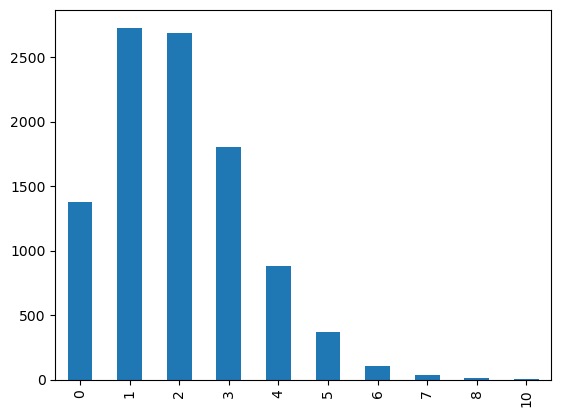

In [78]:
pd.Series(llegadas).value_counts().sort_index().plot(kind = 'bar');

Como antes también es útil usar la acumulada.

Pero por cambiar vamos a calcular la probabilidad de tener más de 4 llegadas en 15 minutos.

Para ello podemos hacer 1 - menos la cdf de 4 llegadas.

In [79]:
prob_5_o_mas = 1 - poisson.cdf(4, mu=2) # Probabilidad de que ocurran 5 o más eventos con una media de 2 eventos por intervalo de tiempo
# lo que es equivalente a 1 menos la probabilidad de que ocurran 4 o menos eventos => 5 o más eventos
prob_5_o_mas * 100

np.float64(5.265301734371109)

La probabilidad de que nos lleguen 5 o más pacientes en una ventana de 15 minutos es del 5,26%

#### Distribuciones continuas


#### Nota Codex - Para qué sirven las distribuciones

Una distribución no es solo un dibujo: es un modelo de incertidumbre. Nos permite responder preguntas del tipo: qué valores son esperables, qué valores son raros y qué probabilidad tiene un evento.


**Distribución normal**

Es la distribución más importante y la más utilizada. También llamada curva o campana de Gauss.

Ya que es la que se produce cuando una variable está compuesta de otras muchas variables.

Y eso es lo más frecuente en casi cualquier ámbito.

Por ejemplo el peso de una persona depende de muchos factores: genética, alimentación, edad, etc. Y se demuestra que se distribuye según una normal.

O la inteligencia que también depende de múltiples factores  genéticos y culturales.

Etc.

Además la mayoría de distribuciones, cuando trabajamos con grandes números como es el caso de data science, convergen hacia la normal.

La normal se define por dos parámetros: la media y la desviación típica.

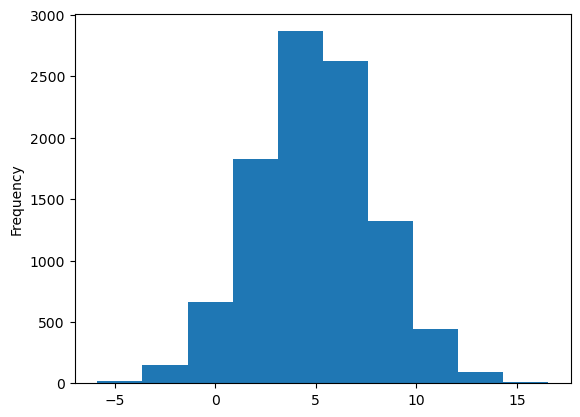

In [80]:
#Ejemplo de una normal
#Loc es la media y scale es la desviación típica
from scipy.stats import norm
normal = norm.rvs(size=10000,loc = 5, scale = 3)
pd.Series(normal).plot(kind = 'hist');

**Otras distribuciones**

Existen otras distribuciones, como la F de Snedecor que se usa para el contraste de igualdad de varianzas, o la T de student que es una normal para cuando tenemos poca muestra o desconocemos la varianza poblacional. 

Esta última tiene más relevancia, ya que la usaremos en ciertos casos del contraste de hipótesis.

Pero quédate simplemente con que es como una normal pero con mayor densidad en las colas.

### Teorema del Límite Central

Es uno de los teoremas más importantes de la estadística, ya que es el que nos va a permitir aplicar con seguridad todo lo que veremos en los apartados siguientes.

Básicamente consiste en que se ha demostrado que si hacemos medias sobre muchas muestras aleatorias de una población, la distribución resultante de todas esas medias se va a distribuir según una normal, **da igual cual fuera forma de la distribución original en la población**.

El conjunto de esas medias sobre sobre muchas muestras aleatorias de una población es a su vez una distribución, y se llama **distribución muestral**.

Pero además dice que:

1. La media de la distribución muestral tiende a converger a media de la población. Por tanto podemos usar el dato de la distribución muestral como válido en la población
2. La variabilidad de la distribución muestral, que se llama **error típico** (o también lo verás como error estandar), va a ser igual a la desviación típica de la población dividida por la raiz cuadrada del tamaño de la muestra

Osea que si sabemos la media de la distribución muestral estamos muy cerca de la media real de la población.

Pero **en cada una de las muestras** de la distribución muestral (que será lo que manejemos en la realidad, una sola de esas muestras) esa media va tener un valor parecido pero diferente a las demás muestras. Es decir, es un dato que tiene una variabilidad.

Si esa variabilidad (el error típico) es grande significa que esa media que estamos sacando en nuestra muestra puede no ser buena estimación de la media real en la población.

Pero si es pequeña significa que esa estimación sí está más cerca del valor real en la población.

Y como el denominador del error típico incluye el tamaño muestral, pasará que cuanto mayor sea la muestra menor será la variabilidad, es decir, más precisa será la media muestral con respecto a la de la población.

En la práctica, como no tenemos la desviación típica de la población, se sustituye por la desviación típica de la muestra, de forma que usando la fórmula del punto 2) podremos estimar el error típico de la distribución muestral a partir de la desviación típica de la muestra.

Pero aquí hay mucha miga, así que vamos paso a paso.

Vamos a crear una distribución simulando una población con otra forma, por ejemplo una exponencial

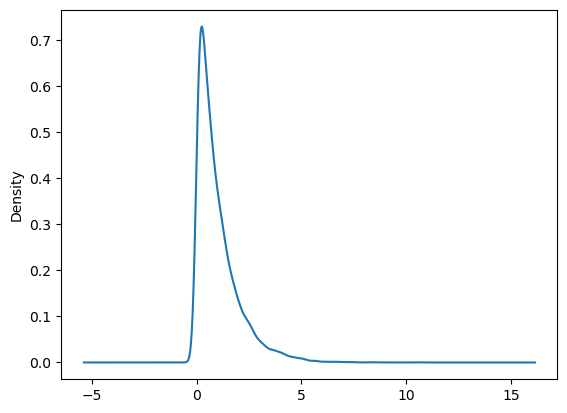

In [81]:
from scipy.stats import expon
# Loc es la media y scale es la desviación típica
# Es una distribución no normal 
poblacion = expon.rvs(loc=0, scale=1,size=10000)
pd.Series(poblacion).plot(kind = 'density');

Ahora sobre la población vamos a extraer 500 muestras aleatorias de tamaño 500 cada una de ellas. Y por tanto tendremos una **distribución muestral**.

In [82]:
random.seed(1234)
muestras = [random.sample(list(poblacion), 500) for i in range(500)]
medias = [np.array(muestra).mean() for muestra in muestras]
#Visualizamos las 10 primeras
medias[0:10]

[np.float64(1.0431491239756623),
 np.float64(0.9917219701446343),
 np.float64(1.0463210012530282),
 np.float64(1.040291361223549),
 np.float64(1.0302913587027576),
 np.float64(1.0187420859647056),
 np.float64(0.9463549458296524),
 np.float64(1.0404254239039257),
 np.float64(1.016904204705001),
 np.float64(1.0171277055831836)]

Calculamos la media en la población y en la distribución muestral para ver que efectivamente tiende a converger.

Y también graficamos la distribución muestral para ver que es una normal.

La media de la población es: 1.001776
Y la media de la distribución muestral es: 1.002257


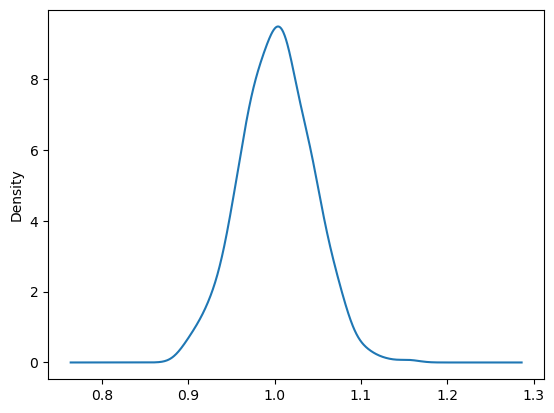

In [83]:
media_poblacion = poblacion.mean()
media_muestras = np.array(medias).mean()

print('La media de la población es: %f'%media_poblacion)
print('Y la media de la distribución muestral es: %f'%media_muestras)

# Ahora la distribución muestral de medias se aproxima a una normal, aunque la población no lo sea
pd.Series(medias).plot(kind = 'density');

Ahora bien, en la práctica no tendremos 500 muestras, si no que tendremos un dataset que podemos entender como una sola de esas muestras, y sobre ese dataset haremos nuestros análisis y calcularemos nuestros datos.

Por tanto no tendremos esos datos de la distribución muestral de las 500, solo podemos usar los datos que tenemos.

Y por tanto asumimos que la media poblacional será igual a la media que nos ha salido en nuestra muestra.

Sabemos que eso no es exacto, pero ¿podemos calcular qué error estamos cometiendo al asumirlo? 

Ahí es donde volvemos a usar el teorema del límite central, que nos dice que el error típico de la distribución muestral será igual a la desviación típica encontrada en la muestra dividida por la raiz cuadrada del tamaño de la muestra.

Por ejemplo vamos a coger una de las muestras y calcular la media y el error típico a partir de ella.

In [84]:
muestra = muestras[0]

# Esta es la muestra que nos tocó, una de las 500 muestras que tomamos de la población
media_muestra = np.array(muestra).mean()
desv_tip_muestra = np.array(muestra).std()
error_tipico = desv_tip_muestra / math.sqrt(500)

print('La media de la muestra es: %f'%media_muestra)
print('El error típico según el teorema del límite central es: %f'%error_tipico)

La media de la muestra es: 1.043149
El error típico según el teorema del límite central es: 0.046549


**EN CONCLUSIÓN**, ahora ya tenemos:

* Que podemos usar para nuestros cálculos la distribución normal

* Un valor estimado para la media poblacional a partir de la media de la muestra, aunque sabemos que no es exacto

* Una cuantificación del error que podemos estar cometiendo a partir del error típico

¿Podemos calcular a partir de esto entre qué valores se puede encontrar realmente la media de la población?

Justamente resolver esa pregunta es lo que se llama calcular el "Intervalo de Confianza"

### Cálculo de intervalos de confianza


#### Nota Codex - Interpretación correcta del intervalo

Un intervalo de confianza del 95% no significa que haya un 95% de probabilidad de que el parámetro esté dentro de este intervalo concreto. La lectura más correcta es: si repitiéramos muchas veces el proceso de muestreo, aproximadamente el 95% de los intervalos construidos así contendrían el verdadero parámetro poblacional.


Nos habíamos quedado en que tenemos un dato (la media en nuestra muestra) que se aproxima al dato real en la población, pero que puede no ser exactament el dato real.

Es decir, usando ese dato de la muestra como aproximación estamos cometiendo un error.

##### Margen de error

Parte de ese error viene explicado por la variabilidad, que la calculábamos con el error típico.

Pero habíamos visto que el error típico es la desviación típica de la distribución muestral. 

Es decir, que si nos alejamos una desviación típica de la media el error que podemos estar cometiendo era en nuestros datos de 0.04. (Esto habría que hacerlo tanto por la derecha como por la izquierda).

Pero entonces si nos alejamos 2 desviaciones típicas estaríamos cometiendo un posible error de 0.08 (por cada lado).

Cuantas más desviaciones típicas nos alejemos más amplio será el rango que demos como solución (intervalo de confianza) pero más seguros estaremos de que la media poblacional real estará en ese rango (nivel de confianza).

Es decir, que la otra parte del error depende de nuestra decisión, viene dado por cuanto queramos nosotros alajarnos de la media.

En definitiva el **margen de error será igual al error típico multiplicado por el número de desviaciones típicas que queramos alejarnos**.

margen de error = error típico * número desviaciones típicas

Si lo descomponemos tenemos que:

El margen de error depende de:

* la variabilidad de lo que estemos midiendo: esto no lo podemos controlar
* el tamaño muestral: a mayor tamaño menor error
* el número de desviaciones típicas que queramos alejarnos, que lo definimos nosotros en función del nivel de confianza que queramos aplicar

##### Niveles de confianza

Pero si el número de desviaciones típicas que nos queremos alejar lo decidimos nosotros ... ¿En qué nos podemos basar para decidirlo?.

Aquí entra el concepto de **niveles de confianza**.

Imagínate que pienso un número del 1 al 10 y tienes que adivinarlo.

Para ello te dejo que digas un intervalo de números.

Por ejemplo, si te dejara un intervalo de 5 números, ¿cómo de confiado estarías en acertar?. Pues un 50% no?

Y si te dejara un intervalo de 9 números, ¿cómo de confiado estarías en acertar?. Pues un 90%

Ahora bien, en el caso de que mi número estuviera en tu intervalo. ¿Qué error medio estarías cometiendo si hiciéramos el experimento infinitas veces?

* En el caso del intervalo de cinco números estarías cometiendo un error medio de 2.5
* En el caso del intervalo de nueve números estarías cometiendo un error medio de 4.5

Por tanto **cuanto mayor sea el intervalo más seguro vas a estar de que mi número va estar en ese intervalo, pero mayor va a ser también el error medio que estás cometiendo** y por tanto de menor valor será tu dato.

Pues eso es exactamente lo que pasa con los niveles de confianza.

Y dado que habíamos dicho que la distribución poblacional va a ser un distribución normal por el teorema del límite centra, y por tanto conocemos perfectamente su distribución de probabilidad y la relación con las desviaciones típicas.

Por ejemplo sabemos que una normal el 68% de los datos están entre la media y una desviación típica por abajo y otra por arriba.

Por tanto podemos darle la vuelta y decir: si quiero trabajar con una confianza del 68% entonces tengo que marcar un intervalo entre la media +- una desviación típica.

Y así se suele hacer. Primero marcas el nivel de confianza al que quieres trabajar y después calculas cuantas desviaciones típicas supone.

Se suelen usar los siguientes estándares:

* 95.5% de nivel de confianza que equivale a 2 desviaciones típicas 
* 99.7% de nivel de confianza que equivale a 3 desviaciones típicas 

Calculemos los datos en nuestro ejemplo y vamos a ver que, al igual que el ejemplo de adivinar el número, si incrementamos la confianza también incrementamos el error.

In [85]:
#recordamos el error típico
error_tipico

np.float64(0.046549376460550546)

In [86]:
#Error muestral con nuestros datos para un nivel de confianza del 95,5%
error_95 = 2 * error_tipico
print(error_95)

#Error muestral con nuestros datos para un nivel de confianza del 99,7%
error_99 = 3 * error_tipico
print(error_99)

0.09309875292110109
0.13964812938165164


##### Distribución normal tipificada

En el punto anterior decíamos que vamos a usar el número de desviaciones típicas que un dato se aleja de la media para cuantificar el nivel de confianza al que estamos trabajando.

Pero sabemos que varias distribuciones, aunque todas sean normales, van a tener distintas medias y distintas desviaciones típicas.

Por ello se suele aplicar una operación que se llama tipificar, y que usaremos también en machine learning, para poder trabajar con un estandar. De hecho a las puntuaciones típicas también se les llama puntuaciones estandar.

La fórmula consiste en tomar cada dato de la distribución, restarle la media, y dividir el resultado por la desviación típica.

El resultado es una métrica que se llama puntuaciones z, o típicas o estandar, y que va a tener una distribución con media cero y desviación típica 1.

Vamos a ver un ejemplo donde primero vamos a generar una distribución normal llamada sin_tipificar, con media 86 y desviacion típica 14.

Y después vamos a tipificarla.

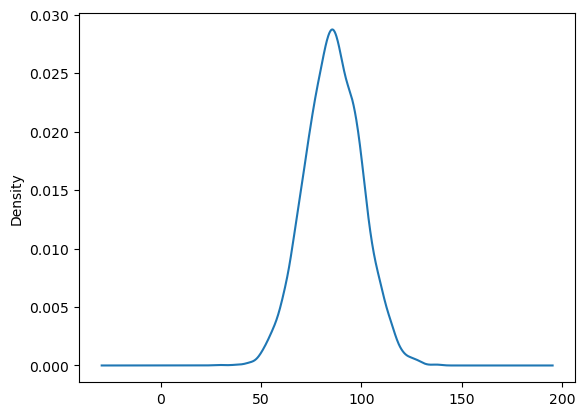

In [87]:
from scipy.stats import norm
# Loc es la media y scale es la desviación típica
sin_tipificar = norm.rvs(size=10000,loc = 86, scale = 14)
pd.Series(sin_tipificar).plot(kind = 'density');

In [88]:
#Vamos a calcular sus estadísticos
media_sin = sin_tipificar.mean()
desv_tip_sin = np.array(sin_tipificar).std()
print('Media: %.2f'%media_sin)
print('Desv Tip: %.2f'%desv_tip_sin)

Media: 85.90
Desv Tip: 13.99


Media: 0.00
Desv Tip: 1.00


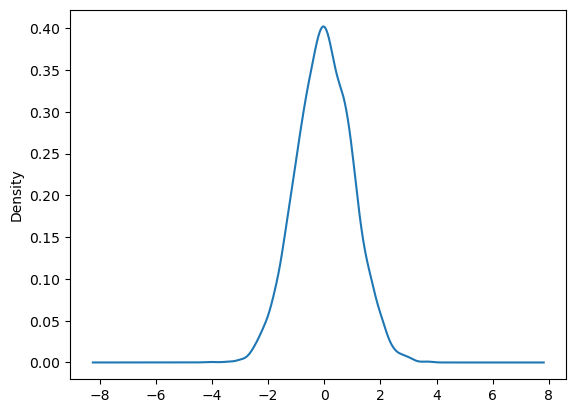

In [89]:
#Ahora vamos a tipificarla y ver que aunque cambien los estadísticos la distribución es igual
tipificada = np.array([(dato - media_sin) / desv_tip_sin for dato in sin_tipificar])

pd.Series(tipificada).plot(kind = 'density');

media_tip = tipificada.mean()
desv_tip_tip = np.array(tipificada).std()
print('Media: %.2f'%media_tip)
print('Desv Tip: %.2f'%desv_tip_tip)

100.00000000000001
15.0


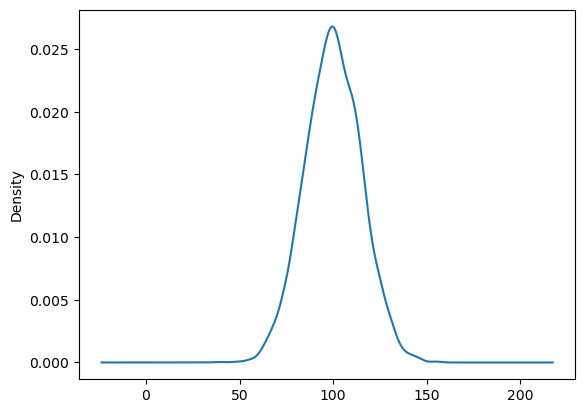

In [90]:
# Aqui vamos a ver une escala de CI,con media 100 y desviación estándar 15, 
# que es una transformación lineal de la tipificación, y por lo tanto la distribución es la misma
escala_qi = 100 + 15 * tipificada

print(escala_qi.mean())
print(escala_qi.std())

pd.Series(escala_qi).plot(kind='density');

##### Intervalos de confianza

Ahora que ya sabemos estimar el margen de error, calcular el intervalo de confianza es muy sencillo.

El límite inferior vendrá dado por la media menos el margen de error.

Y el límite superior vendrá dado por la media más el margen de error.

Por tanto el intervalo entre el que estará el dato real, al nivel de confianza elegido vendrá dado por:

[media - margen de error, media + margen de error]

In [91]:
#Intervalo de confianza en nuestro ejemplo a un NC del 95,5%
media_muestra = np.mean(muestra)

ic_95 = [media_muestra - error_95, media_muestra + error_95]
print(ic_95)

#Intervalo de confianza en nuestro ejemplo a un NC del 99,7%
ic_99 = [media_muestra - error_99, media_muestra + error_99]
print(ic_99)

[np.float64(0.9500503710545611), np.float64(1.1362478768967634)]
[np.float64(0.9035009945940107), np.float64(1.182797253357314)]


A la hora de intrepretarlo podríamos leerlo así:

* Estamos un 95% seguros de que la media real va a estar entre 0.86 y 1.03
* Estamos un 99% seguros de que la media real va a estar entre 0.82 y 1.07

Aunque técnicamente sería más correcto leerlo así:

* Si repitiéramos 100 veces el experimento, en 95 de ellas nos saldría un dato entre 0.88 y 1.05
* Si repitiéramos 100 veces el experimento, en 99 de ellas nos saldría un dato entre 0.84 y 1.09

##### Intervalos de confianza en proporciones

Hemos visto como calcular los intervalos de confianza cuando estamos estimando medias.

Pero el otro gran estadístico que podemos estar usando son las proporciones.

Por ejemplo si una landing ha convertido en un piloto al 13% podemos querer estimar sus intervalos.

Conceptualmente todo es igual, pero cambia una cosa: la fórmula para calcular el error típico.

El error típico para distribuciones muestrales de proporciones se calcular como:

Raiz cuadrada de ((p * q) dividido por n), siendo:

p = la proporción obtenida

q = 1-p

n = tamaño de la muestra

Por ejemplo en el caso anterior habíamos obtenido la proporción de conversión del 0.13 en una muestra de 500 visitantes a la web.

Vamos a calcular su intervalo de confianza con un 95,5% de nivel de confianza.

In [92]:
# Aqui vamos a ver el error típico de una proporción, que es diferente al error típico de una media
error_tipico_prop = math.sqrt((0.13 * 0.87)/500)
print(error_tipico_prop)

0.015039946808416579


In [93]:
# Esto sigue siendo igual, multiplico por 2 para un nivel de confianza del 95,5% y por 3 para un nivel de confianza del 99,7%
error_tipico_prop_95 = error_tipico_prop * 2 
ic_prop_95 = [0.13 - error_tipico_prop_95, 0.13 + error_tipico_prop_95]
ic_prop_95

[0.09992010638316684, 0.16007989361683317]

Es decir, podríamos esperar que si nada cambia esa landing estuviera convirtiendo entre el 9.9% y el 16% cada día.

#### Nota Codex - Por que usar proporciones en vez de medias

Usamos **proporciones** cuando la variable que nos interesa es de tipo si/no, exito/fracaso o pertenece/no pertenece. Por ejemplo: convertir o no convertir, comprar o no comprar, fumar o no fumar, responder o no responder.

En esos casos no queremos saber el valor medio de una cantidad numerica, sino **que parte del total cumple una condicion**. Decir que una landing convierte al `13%` significa que 13 de cada 100 visitantes convierten.

La media responde a preguntas como: *cuanto gastan de media los clientes?* La proporcion responde a preguntas como: *que porcentaje de clientes compra?* Por eso, cuando el dato final es binario, la proporcion suele ser la medida natural.



**¿Para qué nos sirve esto en data science?**

En data science raras veces estaremos haciendo estimación de intervalos como tal, pero sí es algo muy frecuente en ciertas técnicas como por ejemplo el forecast, donde además de obtener la salida de la predicción del modelo podemos pedir al software que saque los intervalos de confianza de esa predicción.

Es decir, en vez de estimar que el mes que viene venderemos 180.000€ es más seguro estimar que venderemos entre 172.000€ y 188.000€.

Además cuando los intervalos son muy amplios sabemos que hay mucho margen en la predicción y por tanto hay que tratarla con precaución.

También es muy usado en casos como la planificación de la demanda, donde siempre deberemos trabajar con un "colchón de seguridad" para no quedarnos sin stock, y los intervalos nos ayudan a calcular ese colchón.

Y también es usado para calcular el tamaño correcto que debería tener una muestra para poder trabajar a unos niveles de confianza y de error determinados.

Por la importancia del muestreo vamos a verlo en su propio apartado.

### Muestreo

Aún en tiempos de Big Data el muestreo sigue siendo muy útil en data science.

Aunque la capacidad de computación sea cada vez mayor, la cantidad de datos y de análisis y modelos que hay que hacer en contextos empresariales tampoco para de crecer.

El muestreo ha demostrado su efectividad para el tipo de análisis que hacemos en data science. Siendo que los modelos construídos sobre una muestra bien realizada son igual de válidos y potentes que los realizados sobre toda la población.

Por lo que, aunque tuviéramos la fuerza bruta necesaria para procesar miles de veces toda la información no tiene ningún sentido hacerlo. Y casi siempre se trabaja con muestras para el desarrollo, que después ya se implantará sobre toda la población.

Es cierto que precisamente debido a la abundancia de datos muchas veces el muestreo se hace "a ojo" sabiendo que vas a cumplir los grandes números suficientes para que, siempre que sea aleatorio, sea correcto.

Pero aquí te voy a enseñarlo a hacerlo correctamente, que siempre es lo ideal.

De todas formas, insisto, lo más importante siempre es que para que funcione la muestra tiene que ser aleatoria.

##### Fórmula para calcular el tamaño de la muestra

Hay que aclarar que de nuevo existen muchas fórmulas dependiendo de la situación. Pero en data science casi siempre trabajaremos con poblaciones infinitas (>100.000).

Cuando vimos el error muestral ya teníamos el tamaño de la muestra incluído en esa ecuación. Recordamos:

margen de error = (desviación típica de la muestra / raiz del tamaño muestral) * número desviaciones típicas

Por tanto sólo necesitamos despejar el tamaño muestral en esa ecuación. Con un añadido, y es que lógicamente antes de hacer la muestra no conocemos su desviación típica, así que se cambia esa variable por la situación de variaza máxima, que en estadística se obtiene como p * q, es decir 0.5 * 0.5.

Por tanto la fórmula final para calcular el tamaño muestral es:

In [94]:
#muestra = ((z**2) * (50*50)) / (me ** 2)
# es el despeje de la fórmula del error muestral para una media, donde z es el valor crítico de la distribución normal para un nivel de confianza dado, 50 es la desviación estándar poblacional (si se conoce) y me es el margen de error deseado.

#### Nota Codex - Formula del tamano muestral para poblaciones grandes

La formula:

`muestra = ((z**2) * (50*50)) / (me ** 2)`

se usa para estimar cuantas personas necesitamos encuestar cuando trabajamos con una **poblacion grande**, normalmente mas de `10.000` personas. En ese caso se suele tratar la poblacion como casi infinita, porque a partir de cierto tamano el ajuste por poblacion finita cambia poco el resultado.

Que significa cada parte:

- `z`: nivel de confianza expresado como valor z. Por ejemplo, `1.96` para un nivel de confianza aproximado del 95%.
- `me`: margen de error maximo que aceptamos, expresado en porcentaje. Por ejemplo, `3` significa +-3%.
- `50*50`: representa el caso mas conservador para una proporcion: `p = 50%` y `q = 50%`. Se usa cuando no sabemos de antemano la proporcion real, porque es el caso que exige mayor tamano de muestra.

Idea clave: si queremos **mas confianza** o **menos margen de error**, necesitamos una muestra mas grande. Por ejemplo, pedir +-3% requiere muchas mas respuestas que aceptar +-5%.



Es decir, que el tamaño de la muestra va a depender de:

* El nivel de confianza al que queramos trabajar: que determinará el z
* El error muestral máximo que queramos cometer

Si queremos trabajar a más NC o cometer menor error deberemos incrementar la muestra.

Por ejemplo:

Calcula el tamaño de muestra necesario si queremos hacer un análisis donde como mucho nos podamos desviar un 3% y con la certeza de que de 100 veces que lo hiciéramos en 95 nos saldrían conclusiones similares

In [95]:
#Vamos a crear una función que calcule el tamaño muestral en base a un NC (pasado como zetas)
# y un margen error (pasado en porcentaje)
def tamaño(z,me):
    tamaño = ((z**2) * (50*50)) / (me ** 2)
    return(tamaño)

#Calculamos
tamaño(1.96,3)

1067.111111111111

### Alpha y pvalor


#### Nota Codex - Alpha y p-valor sin confundirlos

`alpha` es el umbral que eliges antes del test. El `pvalor` es lo que devuelven los datos bajo la hipótesis nula. Si `pvalor < alpha`, rechazamos H0. Si `pvalor >= alpha`, no rechazamos H0. Eso no significa que H0 sea verdadera; significa que no tenemos evidencia suficiente contra ella.


Cuando estemos ya en la práctica real, vamos a encontrarnos muy frecuentemente con dos conceptos: alpha y p-valor.

Por ejemplo, cuando usemos modelos estadísticos como las regresiones lineales, Python nos devolverá p-valores para los coeficientes. Y con eso sabremos si ese coeficiente es significativo estadísticamente o simplemente ha salido por casualidad.

Con lo que ya has aprendido, no solo vas a saber usar el alpha y el p-valor, sino que también vas a entender por qué existen y cómo se interpretan.

####  ¿Qué es el alpha?

alpha = 1 - nivel de confianza

Si trabajamos a un nivel de confianza del 95%, entonces alpha = 0.05 (o 5%).

Este valor es nuestro umbral. Si el p-valor es menor que alpha, consideramos que el resultado es estadísticamente significativo.

####  ¿Qué es el p-valor?

El p-valor es la probabilidad de obtener un resultado tan extremo o más extremo que el observado, asumiendo que la hipótesis nula es cierta.

Es decir, si bajo la hipótesis nula la media real fuera 100, y nosotros obtenemos una media de 108 con un p-valor de 0.02, eso quiere decir que:

Hay solo un 2% de probabilidad de que un resultado como 108 (o más extremo) ocurra por puro azar si la media real fuera realmente 100.

Y ahí es donde entra el alpha. Si nosotros definimos un alpha = 0.05, y el p-valor es menor que alpha, eso significa que es poco probable que ese resultado haya ocurrido por azar, y por tanto rechazamos la hipótesis nula.

####  ¿Y si el p-valor no es menor que alpha?

Entonces no podemos rechazar la hipótesis nula con ese nivel de confianza. 

Eso no significa que la hipótesis nula sea cierta, simplemente que no tenemos pruebas suficientes para rechazarla.

Este matiz es importante: en estadística no se acepta la hipótesis nula, simplemente se rechaza o no se rechaza.

### Una cola o dos colas


#### Nota Codex - Regla práctica sobre colas

Usa dos colas si preguntas: `¿hay diferencia?`. Usa una cola solo si antes de mirar los datos tu pregunta ya tiene dirección: `¿es mayor?` o `¿es menor?`. Si dudas, dos colas es la opción más conservadora.


Hay un aspecto más que debemos tener en cuenta: si estamos usando una prueba de una cola o una de dos colas.

Si queremos saber simplemente si hay diferencia (por arriba o por abajo), usamos una prueba de dos colas.

Si queremos saber si es mayor o menor (pero solo en una dirección), usamos una prueba de una cola.

Ejemplos de casos de dos colas:

* Control de calidad: nuestros tornillos tienen que medir 5cm. Estarán mal tanto si miden menos como si miden más
* Regresiones: el parámetro es diferente de cero

Ejemplos de casos de uso de una cola:
* Conversión de la nueva página web: solo me interesa comprobar que convierte más que la anterior
* Satisfacción de clientes: solo nos importa que no baje de su nivel actual

####  Colas en la práctica

En la mayoría de librerías de Python, el test que se realiza por defecto es de dos colas.

Por tanto me devuelve el pvalor de dos colas.

**Si mi prueba es de dos colas:**

Proceder como lo explicado: 

Si p-valor < alpha --> rechazamos la hipótesis nula y decimos que el resultado es estadísticamente significativo

Si el p-valor >= alpha, entonces no la rechazamos, porque no tenemos suficiente evidencia.

**Pero si mi prueba es de una cola:**

Hay que dividir el pvalor entre 2

Y aplicar las reglas sobre el nuevo valor:

Si p-valor_1cola < alpha --> rechazamos la hipótesis nula y decimos que el resultado es estadísticamente significativo

Si el p-valor_1cola >= alpha, entonces no la rechazamos, porque no tenemos suficiente evidencia.

In [96]:
from scipy import stats

# Desactivo notación científica en numpy
np.set_printoptions(suppress=True)

# Creamos unos datos
np.random.seed(42)
datos = np.random.normal(loc=1000, scale=55, size=1000)

# Testamos: H0 la media en la población es 998, H1: es diferente de 998 (por arriba o por abajo)
t, p_valor_2colas = stats.ttest_1samp(datos, popmean=998)

p_valor_2colas

np.float64(0.07237814144744951)

#### Nota Codex - Alpha, p-valor y por que dividimos entre 2 en una prueba unilateral

Antes de mirar el codigo, separa dos ideas:

| Concepto | Que es | Cuando se decide |
|---|---|---|
| **alpha** | El riesgo maximo de equivocarnos que aceptamos. Por ejemplo, `0.05`. | Antes del test |
| **p-valor** | La probabilidad de observar un resultado tan extremo como el obtenido si `H0` fuera cierta. | Despues de ver los datos |

La regla de decision es:

```text
si p-valor < alpha      -> rechazamos H0
si p-valor >= alpha     -> no rechazamos H0
```

##### Dos colas frente a una cola

En una prueba de **dos colas**, preguntamos si hay diferencia en cualquier direccion:

```text
H0: media = 998
H1: media != 998
```

Aqui el p-valor reparte la rareza entre los dos extremos de la distribucion: valores muy bajos y valores muy altos.

En una prueba de **una cola**, preguntamos solo por una direccion:

```text
H0: media <= 998
H1: media > 998
```

Aqui solo nos interesa la cola derecha, porque queremos saber si la media es **mayor** que 998.

##### Entonces, por que aparece esta linea?

```python
p_valor_1cola = p_valor_2colas / 2
```

Porque muchas funciones de Python devuelven por defecto el **p-valor de dos colas**. Si la distribucion es simetrica, ese p-valor cuenta las dos direcciones posibles. Cuando nuestra hipotesis alternativa solo mira una direccion, nos quedamos solo con una de esas dos mitades.

```text
p-valor dos colas = rareza izquierda + rareza derecha
p-valor una cola  = solo la rareza de la direccion que nos interesa

p_valor_1cola = p_valor_2colas / 2
```

Ejemplo:

```text
p_valor_2colas = 0.08
p_valor_1cola  = 0.08 / 2 = 0.04
```

Con `alpha = 0.05`, el resultado no seria significativo a dos colas (`0.08 > 0.05`), pero si podria serlo a una cola (`0.04 < 0.05`).

##### Condicion importante

Esta division solo tiene sentido si el estadistico va en la direccion de `H1`.

En el codigo de abajo estamos probando si la media es **mayor** que 998. Por eso:

- si `t > 0`, los datos van hacia la derecha y usamos `p_valor_2colas / 2`;
- si `t <= 0`, los datos van en la direccion contraria, asi que no podemos rechazar `H0` y ponemos `p_valor_1cola = 1.0`.

Idea clave: **dividir entre 2 no es una receta automatica; solo se hace cuando la prueba es unilateral y el resultado va en la direccion que habiamos planteado antes de mirar los datos**.



In [98]:
# Convertir un p-valor de dos colas a una cola
# H0: la media poblacional es menor o igual que 998
# H1: la media poblacional es mayor que 998
#
# Muchas funciones devuelven p-valor de dos colas por defecto.
# Si t > 0, el resultado va en la direccion de H1, asi que nos quedamos con una sola cola:
# p_valor_1cola = p_valor_2colas / 2
#
# Si t <= 0, el resultado va en la direccion contraria.
# En ese caso no tiene sentido dividir entre 2: no podemos rechazar H0.

if t > 0:
    p_valor_1cola = p_valor_2colas / 2
else:
    p_valor_1cola = 1.0

p_valor_1cola



np.float64(0.03618907072372476)

Truco: Si no estás seguro de cuantas colas es tu problema usa 2 colas (la salida por defecto).

Está aceptado por ser la opcion más conservadora.

### Contraste de hipótesis


#### Nota Codex - Lo que un test no puede decir

Un test de hipótesis no prueba que H0 sea verdadera ni que H1 sea definitivamente cierta. Solo evalúa si los datos observados son compatibles con H0 bajo un nivel de exigencia definido.


##### Hipótesis nula e hipótesis alternativa

Prácticamente cualquier inferencia que queramos hacer podemos plantearla como el contraste de una hipótesis.

Por ejemplo en la hipótesis de si el valor de la media en la población podría ser de 100 o no.

Vemos que realmente no es una hipótesis, si no dos. Lo que se llaman:

* Hipótesis nula
* Hipótesis alternativa

La **hipótesis nula** en la mayoría de pruebas estadísticas suele ser que no hay "efecto".

Por ejemplo si estamos comparando la efectividad de dos medicamentos, que no haya efecto aquí significa que ambos medicamentos van a tener resultados similares.

O si estamos contratando un coeficiente de una variable de un modelo, que no haya efecto significa que ese coeficiente podría ser cero, y por tanto esa variable no sería predictiva.

Normalmente la hipótesis nula es lo que nos gustaría "rechazar".

Por el contrario, la **hipótesis alternativa** es que sí existe efecto, y normalmente es lo que buscamos.

Por ejemplo en el caso de los medicamentos nos gustaría que sí hubiera diferencias. Por tanto:

* La hipótesis nula será que el resultado provocado por los medicamentos es similar
* La hipótesis alternativa será que el resultado provocado por los medicamentos es significativamente diferente

#### Pruebas de contraste de hipótesis

Generalizando todo lo que hemos visto hasta ahora tenemos que:

1. Tenemos una distribución conocida, la normal, bien porque la variable original ya era normal o bien por lo que nos dice el teorema del límite central
2. Tenemos una hipótesis nula que queremos contrastar
3. Elegimos un Nivel de Confianza al cual queremos trabajar, que nos da un Alpha
4. Según la prueba que estemos haciendo usaremos un estadístico u otro, que nos devolverá un Pvalor (si es una cola lo dividimos por 2)
5. Si el Pvalor es menor que el Alpha entonces rechazamos la hipótesis nula, y por tanto aceptamos la alternativa

En cuanto al estadístico del punto 4 es la parte más compleja, por lo que a nivel práctico y por simplificar, vamos a recoger los 4 principales escenarios que se nos van a presentar y el estadístico que debemos usar en cada caso:

1. Contraste de medias en la población: es decir si la media obtenida puede ser compatible con una media hipotética de la población. Usaremos el estadístico t
2. Contraste de medias entre dos muestras: es decir si la diferencia entre las media de grupos diferentes es significativa o no. Usaremos el estadístico t
3. Contraste de proporciones en la población: es decir si la proporción obtenida puede ser compatible con una porporción hipotética en la población. Usaremos el estadístico z
4. Contraste de proporciones entre dos muestras: es decir si la diferencia entre la proporción de grupos diferentes es significativa o no. Usaremos el estadístico z

Es decir, en la práctica, casi siempre usaremos t para medias (porque rara vez conocemos la desviación poblacional) y z para proporciones (siempre que tengamos muestras suficientemente grandes (>30))

##### **Contraste de medias en la población**

Queremos ver si el valor de la media obtenido en la muestra puede ser compatible con un hipotético valor en la población.

Para ello seguiremos la metodología explicada, usando como estadístico de contraste **la prueba t**.

Usaremos la implementación de Scipy con la función ttest_1samp() ya que estamos usando **el estadístico t** en una sola muestra (no comparamos entre dos muestras)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html

A esta función tenemos que pasarle:

* a: los datos
* popmean: el valor de h0 a contrastar

Como ejemplo vamos a calcular si es posible que la media de total_bill en la población sea de 25$.

In [103]:
#Primero recordamos cual era el valor en nuestra muestra
df.total_bill.mean()

np.float64(19.78594262295082)

In [104]:
#Paso 1: definimos las hipótesis
h0 = 25
#Por tanto h1 es que sea diferente de 25

In [105]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 95%
alpha = 0.05

In [106]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (t sobre una muestra)
p_valor = sp.stats.ttest_1samp(a = df.total_bill, popmean = h0)[1]
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.000


Por tanto vemos que el pvalor es menor que alpha, por tanto no podemos aceptar la H0 y por tanto no es probable que la media de importes en la población sea de 25$.

Vamos a repetir el ejemplo, pero ahora con un valor quizá más probable. Testemos si la media de propinas podría ser de 20$.

In [107]:
#Paso 1: definimos las hipótesis
h0 = 20
#Por tanto h1 es que sea diferente de 20

In [108]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 95%
alpha = 0.05

In [109]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (t sobre una muestra)
# como la h0 es una igualdad dejamos el alternative por defecto
p_valor = sp.stats.ttest_1samp(a = df.total_bill, popmean = h0)[1]
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.708


Ahora pvalor es mayor que alpha, luego no podemos rechazar H0, luego 20$ sí es un valor posible en la población a tenor de los datos de nuestra muestra.

##### **Contraste de medias entre dos muestras**

En este caso lo que queremos ver es si la diferencia obtenida entre 2 medias de dos grupos distintos es o no significativa.

Para ello seguiremos la metodología explicada, usando como estadístico de contraste la **prueba t**.

Usaremos la implementación de Scipy con la función ttest_ind() ya que estamos usando el **estadístico t** en dos **muestras que son independientes** (porque pertenecen a dos poblaciones distintas).

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

A esta función tenemos que pasarle:

* a y b: los datos en forma de arrays numpy
* equal_var: ponerlo a False porque si no asume que ambas poblaciones tienen la misma varianza

Como ejemplo vamos a calcular si hay diferencias significativas entre las cuentas de las mujeres y de los hombres.

In [110]:
#Primero recordamos cual era el valor en nuestra muestra
df.groupby('sex', observed=False).total_bill.mean()

sex
Male      20.744076
Female    18.056897
Name: total_bill, dtype: float64

In [111]:
#Tenemos que crear dos vectores, uno con los hombres y otro con la mujeres
hombres = df.loc[df.sex == 'Male','total_bill']
mujeres = df.loc[df.sex == 'Female','total_bill']

In [96]:
#Paso 1: definimos las hipótesis
#H0: los hombres y las mujeres tienen importes de cuenta similares
#H1: los hombres y las mujeres no tienen importes de cuenta similares

In [112]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 95%
alpha = 0.05

In [113]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (t sobre dos muestras independientes)
p_valor = sp.stats.ttest_ind(a = hombres, b = mujeres, equal_var = False)[1]
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.019


Por tanto vemos que el pvalor es menor que alpha, por tanto no podemos aceptar la H0 y por tanto no es probable que la que la cuenta entre hombres y mujeres sea similar.

Rechazamos h0 y concluímos que las diferencias sí son significativas al 95% de confianza.

Pero vamos a ver si también lo son al 99% de confianza.

In [42]:
#Paso 1: definimos las hipótesis
#H0: los hombres y las mujeres tienen importes de cuenta similares
#H1: los hombres y las mujeres no tienen importes de cuenta similares

In [115]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 99%
alpha = 0.01

In [ ]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (t sobre dos muestras independientes)
p_valor = sp.stats.ttest_ind(a = hombres, b = mujeres, equal_var = False)[1] # equal_var = False => no asumimos varianzas iguales
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.019


Ahora pvalor es mayor que alpha, luego no podemos rechazar H0, luego no podríamos afirmar con un 99% de confianza que la cuenta entre hombres y mujeres sea diferente.

##### **Contraste de proporciones en la población**

Queremos ver si una proporción obtenida en la muestra puede ser compatible con un hipotético valor en la población.

Para ello seguiremos la metodología explicada, usando como estadístico de contraste **la prueba z**.

Scipy no tiene implementación para hacer contrastes de proporciones, así que vamos a usar la implementación del paquete statsmodels, con la función **proportions_ztest()** ya que estamos usando el **estadístico z**, y como es en una sola muestra a los parámetros count y nobs solo les pasaremos un dato a cada uno.

https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html

A esta función tenemos que pasarle:

* count: los éxitos (lo que queremos medir)
* nobs: el tamaño de la muestra
* value: el valor de la hipótesis nula a testar

Como estamos haciendo el contraste contra un dato de la población sólo le pasaremos un valor en count y en nobs, y le pasaremos el value.

Si hiciéramos contraste entre 2 muestras (como en el siguiente ejemplo) entonces tendríamos que pasarle un array con dos números a count y a nobs, y no usaríamos el value.

Como ejemplo vamos a calcular si es posible que el porcentaje de fumadores en la población sea del 40%.

In [125]:
#Primero recordamos cual era el valor en nuestra muestra (en porcentaje)
df.smoker.value_counts(normalize = True)

smoker
No     0.618852
Yes    0.381148
Name: proportion, dtype: float64

In [121]:
#Primero recordamos cual era el valor en nuestra muestra (en absoluto)
df.smoker.value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [122]:
#Paso 1: definimos las hipótesis
h0 = 0.4
#Por tanto h1 es que sea diferente del 40%

In [123]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 95%
alpha = 0.05

In [124]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (z sobre una muestra)
exitos = 93 #fijarse que aquí tenemos que poner los fumadores que son los que nos interesan
muestra = 151 + 93
p_valor = proportions_ztest(count = exitos, nobs = muestra, value = h0)[1]
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.544


Por tanto vemos que el pvalor NO es menor que alpha, por tanto no podemos rechazar la H0 y por tanto sí puede ser que en esta población el 40% de las personas sean fumadoras (al 95% de confianza)

##### **Contraste de proporciones entre dos muestras**

Queremos ver si una diferencia en la proporción obtenida entre dos muestras puede ser estadísticamente significativa.

Para ello seguiremos la metodología explicada, usando como estadístico de contraste la **prueba z**.

Scipy no tiene implementación (hasta donde yo sé) para hacer contrastes de proporciones, así que vamos a usar la implementación del paquete statsmodels, con la función **proportions_ztest()** ya que estamos usando el **estadístico z**, y como son dos muestras, a los parámetros count y nobs les tendremos que pasar un array.

https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportions_ztest.html

A esta función tenemos que pasarle:

* count: los éxitos (lo que queremos medir)
* nobs: el tamaño de la muestra
* value: el valor de la hipótesis nula a testar

Como estamos haciendo el contraste de dos muestras le pasaremos un array con dos números a count y a nobs, y no usaremos el value.

Como ejemplo vamos a calcular si la diferencia entre el porcentaje de fumadores entre hombres y mujeres puede ser significativa.

In [126]:
#Primero recordamos cual era el valor en nuestra muestra (en porcentaje)
pd.crosstab(df.sex, df.smoker,normalize='columns')

smoker,Yes,No
sex,,
Male,0.645161,0.642384
Female,0.354839,0.357616


In [ ]:
#Primero recordamos cual era el valor en nuestra muestra (en absoluto)
pd.crosstab(df.sex, df.smoker)

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [122]:
#Paso 1: definimos las hipótesis
#h0: el porcentaje de fumadores en hombres es igual que en mujeres
#h1: el porcentaje de fumadores en hombres NO es igual que en mujeres

In [127]:
#Paso 2: elegimos un nivel de confianza que nos da un alpha. 
#Elegimos NC = 95%
alpha = 0.05

In [128]:
#Paso 3: calculamos el pvalor según el estadístico de contraste elegido (z sobre dos muestras)
exitos_h = 60
exitos_m = 33
muestra_h = 60 + 97
muestra_m = 33 + 54

#lo pasamos a array porque así lo pide la función
array_exitos = np.array([exitos_h,exitos_m])
array_muestras = np.array([muestra_h,muestra_m])

p_valor = proportions_ztest(count = array_exitos, nobs = array_muestras)[1]
print(f"{p_valor:.3f}")#Esto es para que no salga con notación científica

0.965


Por tanto vemos que el pvalor NO es menor que alpha, por tanto no podemos rechazar la H0 y por tanto al 95% de confianza no podemos decir que los hombres y las mujeres fumen en distinto porcentaje.

**¿Para qué nos sirve esto en data science?**

Como ya hemos comentado en la mayoría de los casos, a nivel práctico, cuando queramos comprobar si el valor de un estadístico que hemos calculado (correlación, chi-cuadrado, coeficientes de modelos, ...) es significativo a nivel poblacional, la prueba ya nos devolverá el pvalor, por lo que solo tendremos que compararlo contra un Alpha, que normalmente será 0.05. 

Si Pvalor < Alpha entonces el valor SI es significativo.

Pero más allá de que sea prácticamente muy sencillo, es conveninete que sepas de donde viene para entenderlo, aplicarlo e interpretarlo correctamente.

**Ejemplo práctico**

Para terminar de afianzar los conceptos vamos a hacer un ejemplo práctico sobre uno de los casos de contraste de hipótesis que posiblemente tengas más oportunidad de realizar. Los test A/B.

En general hacer test A/B es configurar un experimento donde queremos comprobar si hay diferncias significativas entre algo nuevo que queremos probar (grupo tratamiento) y lo que ya estaba funcionando (grupo de control).

Es muy común actualmente por ejemplo en marketing digital, donde podemos tener una versión de una web y queremos comprobar si ciertos cambios hacen o no que suba la conversión.

Lo mismo puede ser aplicado a emails, páginas de venta, etc.

En este caso vamos a suponer que tenemos la web actual que llamaremos A. Y una variación que llamaremos B.

Y vamos a asignar aleatoriamente la A a 1000 de los próximos visitantes y la B a otros 1000 también aleatorios.

Vamos a suponer que es una web para registrarse y que 285 personas se registraron en la A y 321 en la B.

Por tanto la conversión es:

- Conversión A: 28.5%
- Conversión B: 32.1%

¿Esa diferencia es estadísticamente significativa y por tanto podemos cambiar la web con garantías?

¿O quizá esa diferencia puede ser explicada simplemente por el azar muestral y por tanto no deberíamos cambiarla todavía?

La hipótesis nula por tanto es que la web B convierte igual que la A)

La hipótesis alternativa es que B convierte mejor.

Por tanto es una prueba de una cola.

Y vamos a trabajar a un 95% de confianza, por tanto alpha = 0.05.

Ya sabemos que al ser un contraste de proporciones podemos usar el test z.


In [131]:
#Vamos a usar la implementación del test z para proporciones de statsmodels
from statsmodels.stats.proportion import proportions_ztest

conversiones = np.array([321, 285])#Nota, por como funciona proportions_ztest internamente hay que poner primero la alternativa y luego la actual
muestras = np.array([1000, 1000])

z, pval_dos_colas = proportions_ztest(conversiones, muestras)

if z > 0:
    pval_una_cola = pval_dos_colas / 2
    print('pvalor igual a: %.3f por tanto B convierte mejor que A'%pval_una_cola)
else:
    print('B no convierte mejor que A')


pvalor igual a: 0.040 por tanto B convierte mejor que A


Como el pvalor es menor que 0.05 entonces podemos rechazar la hipótesis nula.

Y concluir que la B convierte mejor, y por tanto podemos cambiar la web.


# CONTENIDO CODEX NO PRESENTE EN LA FORMACIÓN OFICIAL

Esta sección complementa la inferencia con conceptos clave para interpretar mejor los tests estadísticos.



## 1. Error de tipo I y error de tipo II

#### Nota Codex

- **Error de tipo I**: rechazar H0 cuando H0 era verdadera. Su probabilidad está controlada por `alpha`.
- **Error de tipo II**: no rechazar H0 cuando H0 era falsa.

En lenguaje práctico: el tipo I es una falsa alarma; el tipo II es no detectar un efecto real.



## 2. Potencia estadística

#### Nota Codex

La potencia es la probabilidad de detectar un efecto cuando el efecto realmente existe. Aumenta con muestras más grandes, efectos más fuertes y menor variabilidad. En experimentos A/B, poca potencia puede hacer que una mejora real parezca no significativa.



## 3. Tamaño del efecto

#### Nota Codex

Un resultado puede ser estadísticamente significativo y aun así ser poco importante en negocio. El tamaño del efecto mide cuánto cambia algo, no solo si cambia.


In [ ]:

# Ejemplo Codex: tamaño del efecto con Cohen's d
import numpy as np

grupo_a = np.array([10, 11, 10, 12, 11, 10])
grupo_b = np.array([13, 12, 14, 13, 12, 14])

diferencia_medias = grupo_b.mean() - grupo_a.mean()
desv_pooled = np.sqrt((grupo_a.var(ddof=1) + grupo_b.var(ddof=1)) / 2)
cohens_d = diferencia_medias / desv_pooled
cohens_d



## 4. Tests paramétricos y no paramétricos

#### Nota Codex

Los tests paramétricos, como el t-test, asumen ciertas condiciones sobre los datos. Si esas condiciones son dudosas, podemos usar alternativas no paramétricas como Mann-Whitney o Wilcoxon.


In [ ]:

# Ejemplo Codex: Mann-Whitney como alternativa no paramétrica
from scipy import stats

stats.mannwhitneyu(grupo_a, grupo_b, alternative='two-sided')



## 5. ANOVA simple

#### Nota Codex

ANOVA sirve para comparar medias entre más de dos grupos. Si solo comparas dos grupos, un t-test suele bastar. Si comparas tres o más, ANOVA evita encadenar muchos t-tests y aumentar el riesgo de falsos positivos.


In [ ]:

# Ejemplo Codex: ANOVA de una vía
g1 = np.array([10, 11, 12, 10])
g2 = np.array([13, 14, 13, 15])
g3 = np.array([9, 8, 10, 9])

stats.f_oneway(g1, g2, g3)



## 6. Tests de normalidad y varianza

#### Nota Codex

Para revisar normalidad puedes usar Shapiro-Wilk. Para comparar varianzas entre grupos puedes usar Levene. No se trata de aplicar tests mecánicamente, sino de entender si las condiciones del análisis son razonables.


In [ ]:

# Ejemplo Codex: Shapiro y Levene
print(stats.shapiro(grupo_a))
print(stats.levene(grupo_a, grupo_b))



## 7. Checklist Codex para inferencia

1. Define claramente H0 y H1.
2. Decide alpha antes de mirar el resultado.
3. Elige una o dos colas según la pregunta.
4. Comprueba si el test elegido tiene sentido para tus datos.
5. Interpreta p-valor, intervalo de confianza y tamaño del efecto juntos.
6. Recuerda que significancia estadística no siempre implica importancia práctica.
